In [4]:
!pip install numpy==2.2.0
!mamba install pandas==2.2.3
!mamba install scikit-learn
!pip install matplotlib==3.9.3

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas==2.2.3
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.028 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        2.2.3                         np22py313hb4e6ec2_0           emscripten-forge              
+ python-tzdata                 2026.1                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidge

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv')
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
796,2014,MINI,COOPER S COUNTRYMAN ALL4,COMPACT,1.6,4,A6,Z,10.0,7.8,9.0,31,207
1021,2014,VOLKSWAGEN,BEETLE CONVERTIBLE,SUBCOMPACT,2.0,4,A6,Z,10.3,8.1,9.3,30,214
942,2014,SUBARU,BRZ,MINICOMPACT,2.0,4,AS6,Z,9.6,7.1,8.5,33,196
432,2014,GMC,ACADIA,SUV - STANDARD,3.6,6,A6,X,14.3,9.9,12.3,23,283
427,2014,FORD,TAURUS FFV AWD,FULL-SIZE,3.5,6,AS6,E,18.4,12.5,15.7,18,251


In [7]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [10]:
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',], axis=1)

In [11]:
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [12]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',], axis=1)

In [13]:
df.corr()

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,-0.808554,0.874154
FUELCONSUMPTION_COMB_MPG,-0.808554,1.000000,-0.906394
CO2EMISSIONS,0.874154,-0.906394,1.000000


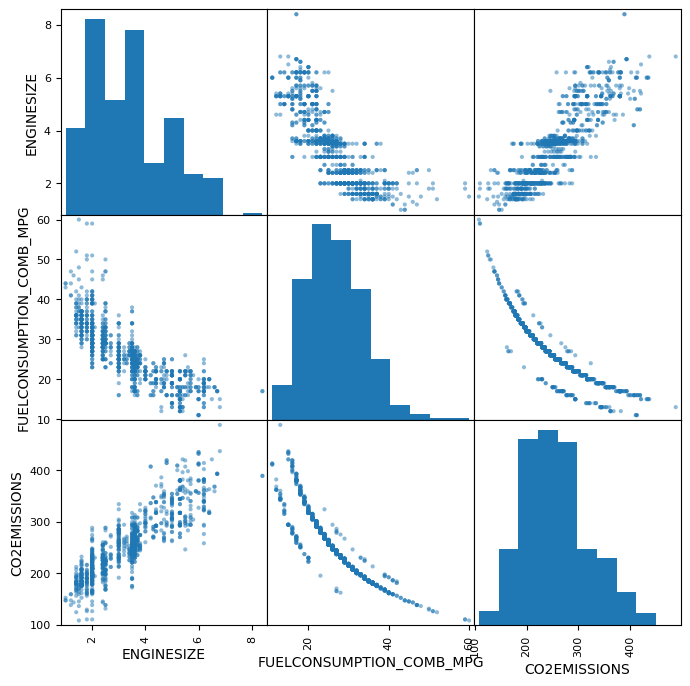

In [21]:
# Change marker size and style
plt.rcParams.update({'scatter.marker': 'o', 'scatter.edgecolors': 'black'})
pd.plotting.scatter_matrix(df, alpha=0.5, figsize=(8, 8),  diagonal='hist', )
plt.show()

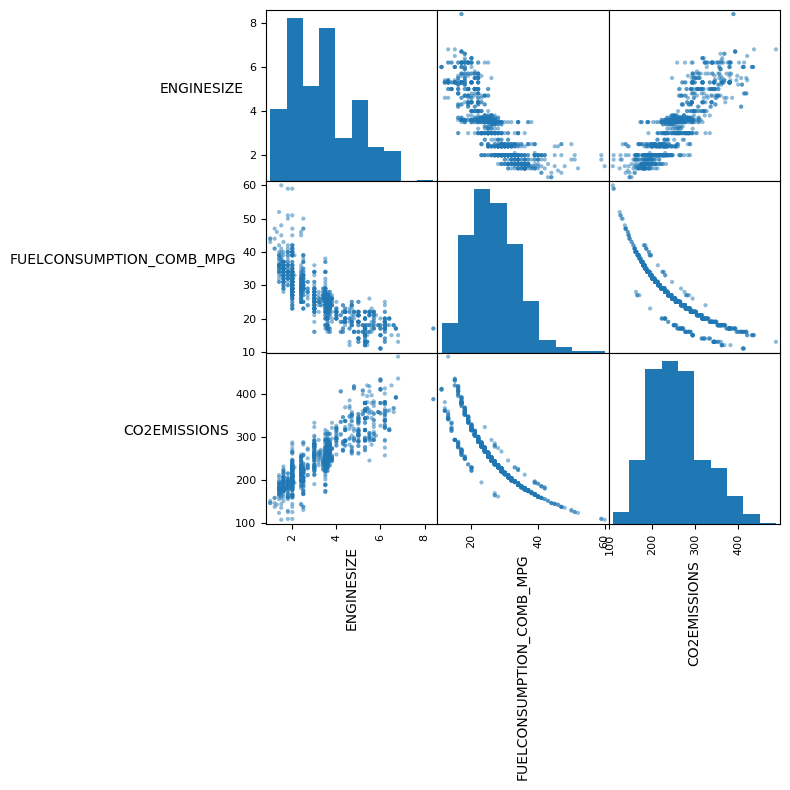

In [23]:
axes = pd.plotting.scatter_matrix(df, alpha=0.5, figsize=(8, 8),  diagonal='hist')
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

In [24]:
X = df.iloc[:,[0,1]].to_numpy()

In [25]:
X

array([[ 2. , 33. ],
       [ 2.4, 29. ],
       [ 1.5, 48. ],
       ...,
       [ 3. , 24. ],
       [ 3.2, 25. ],
       [ 3.2, 22. ]], shape=(1067, 2))

In [26]:
y = df.iloc[:, [2]].to_numpy()
y

array([[196],
       [221],
       [136],
       ...,
       [271],
       [260],
       [294]], shape=(1067, 1), dtype=int64)

In [27]:
print("Boolean DataFrame:\n", df.isnull())
print("\nCount of NaN in each column:\n", df.isnull().sum())

Boolean DataFrame:
       ENGINESIZE  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS
0          False                     False         False
1          False                     False         False
2          False                     False         False
3          False                     False         False
4          False                     False         False
...          ...                       ...           ...
1062       False                     False         False
1063       False                     False         False
1064       False                     False         False
1065       False                     False         False
1066       False                     False         False

[1067 rows x 3 columns]

Count of NaN in each column:
 ENGINESIZE                  0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64


In [29]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)
X_std

array([[-0.9512918 ,  0.87855306],
       [-0.66865251,  0.34273362],
       [-1.30459092,  2.88787597],
       ...,
       [-0.24469358, -0.32704069],
       [-0.10337393, -0.19308583],
       [-0.10337393, -0.59495041]], shape=(1067, 2))

In [30]:
pd.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

In [35]:
from sklearn import linear_model
regressor = linear_model.LinearRegression()
regressor.fit(X_train, y_train)
coef_ = regressor.coef_
intercept_ = regressor.intercept_

print('Coefficients: ', coef_)
print('Intercept: ', intercept_)


Coefficients:  [[ 25.27339614 -37.4381472 ]]
Intercept:  [256.29072488]


In [36]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)

Coefficients:  [[17.8581369  -5.01502179]]
Intercept:  [329.1363967]


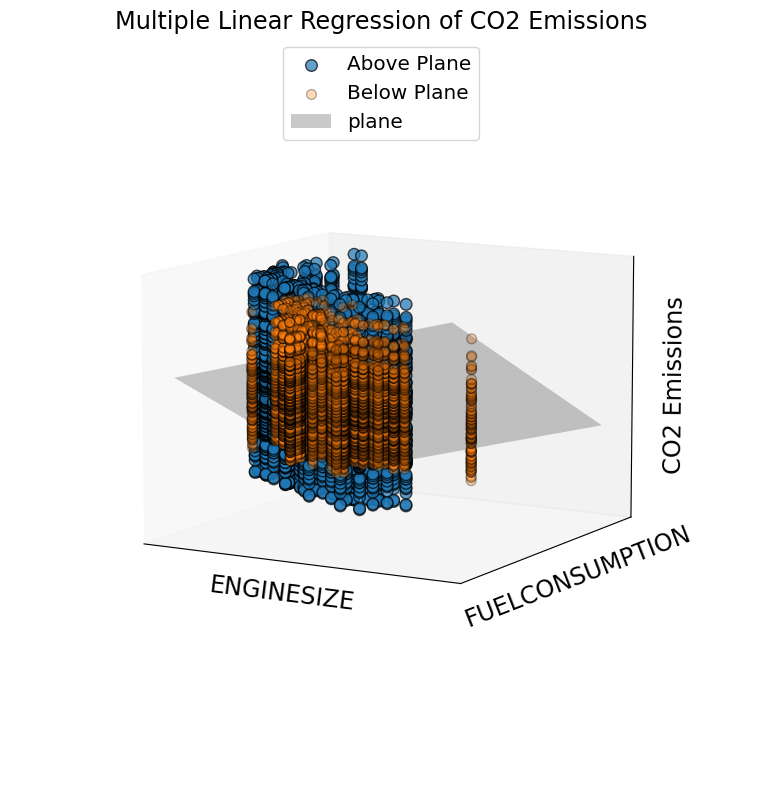

In [37]:
#from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],  label="Above Plane",s=70,alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],  label="Below Plane",s=50,alpha=.3,ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plane')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()

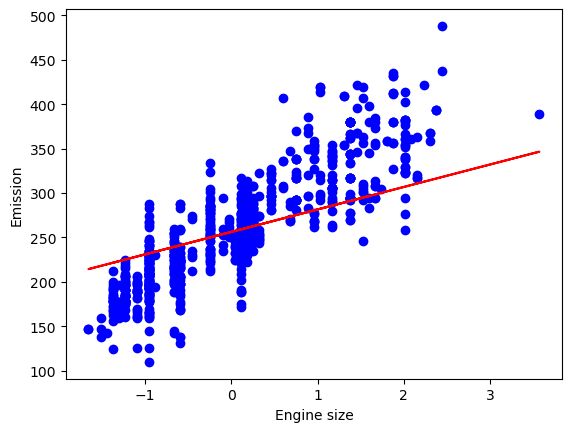

In [38]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

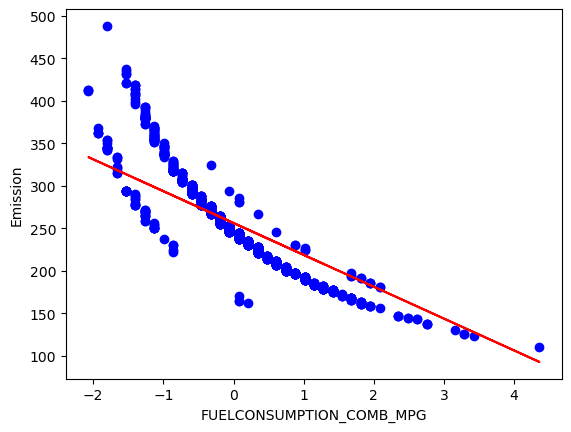

In [39]:
plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()

In [62]:
X_train_1 =  X_train[:,0]


In [63]:
X_train_1

array([-1.37525074,  0.74454394, -0.24469358, -0.24469358,  1.38048235,
        0.74454394,  0.24992518, -0.9512918 ,  0.46190465,  0.17926536,
        0.6032243 , -0.66865251,  2.22840022,  1.16850288,  1.66312164,
        0.24992518,  2.01642075,  0.10860554,  0.17926536, -0.66865251,
        0.17926536, -0.9512918 , -0.9512918 , -0.59799269, -1.37525074,
        0.17926536,  0.17926536,  0.17926536,  0.46190465, -0.9512918 ,
        0.10860554,  1.59246182, -0.59799269,  0.46190465,  0.10860554,
       -1.23393109, -0.9512918 ,  0.10860554,  1.38048235,  0.24992518,
       -0.9512918 ,  2.29906004,  0.24992518,  1.59246182,  0.17926536,
        2.01642075, -0.24469358, -1.37525074,  0.74454394,  0.67388412,
        1.16850288,  0.24992518, -0.9512918 ,  0.17926536, -0.66865251,
        1.38048235,  1.66312164,  1.52180199, -1.23393109, -0.24469358,
        0.10860554,  0.46190465, -0.24469358, -1.23393109, -0.66865251,
       -0.24469358,  0.17926536, -1.37525074, -0.66865251, -0.95

In [64]:
regressor_1 = linear_model.LinearRegression()
regressor_1.fit(X_train_1.reshape(-1, 1), y_train)
coef_1 = regressor_1.coef_
intercept_1 = regressor_1.intercept_

print('Coefficients: ', coef_1)
print('Intercept: ', intercept_1)

Coefficients:  [[55.18408797]]
Intercept:  [256.77183014]


Text(0, 0.5, 'Emission')

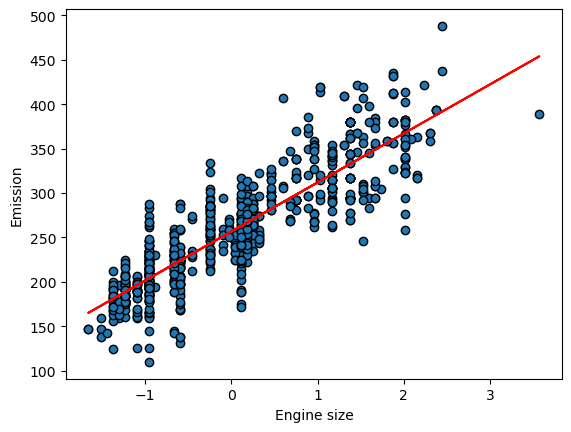

In [65]:
# Enter your code here
plt.scatter(X_train_1, y_train)
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

Text(0, 0.5, 'CO2 Emission')

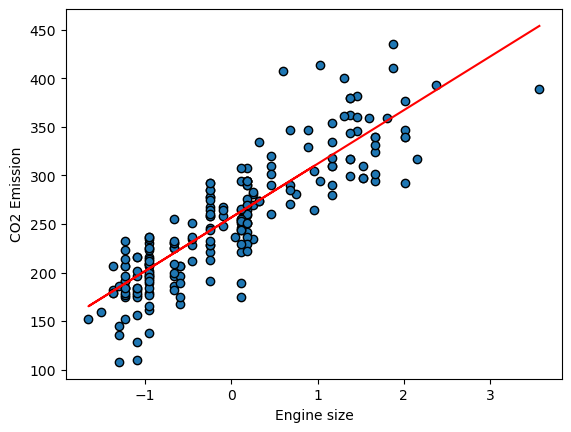

In [69]:
# Enter your code here
X_test_1 = X_test[:,0]
plt.scatter(X_test_1, y_test)
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("CO2 Emission")

In [70]:
X_train_2 =  X_train[:,1]

In [71]:
X_train_2

array([ 1.28041764, -0.59495041,  0.34273362, -0.19308583, -1.26472471,
       -0.99681499, -0.05913096,  0.20877876, -0.86286013, -0.59495041,
       -0.99681499,  0.47668848, -1.53263443, -0.99681499, -1.26472471,
       -0.46099555, -1.13076985, -0.32704069, -0.32704069,  0.20877876,
       -0.86286013,  2.48601138,  0.0748239 ,  0.34273362,  1.14646278,
       -1.26472471, -0.46099555, -1.26472471, -0.59495041,  0.47668848,
        1.01250792, -0.46099555,  0.34273362, -0.46099555, -0.46099555,
        1.14646278,  0.7445982 ,  1.4143725 , -1.26472471, -0.32704069,
        1.14646278, -1.13076985, -0.05913096, -0.59495041, -0.05913096,
       -1.80054415,  0.0748239 ,  1.28041764, -0.59495041, -0.32704069,
       -0.72890527, -0.59495041,  0.47668848, -0.19308583,  0.61064334,
       -0.86286013, -0.72890527, -0.59495041,  1.14646278, -0.46099555,
        0.0748239 , -0.59495041,  0.20877876,  1.4143725 ,  0.47668848,
        1.01250792, -0.05913096,  1.54832736, -0.19308583,  1.81

In [72]:
regressor_2 = linear_model.LinearRegression()
regressor_2.fit(X_train_2.reshape(-1, 1), y_train)
coef_2 = regressor_2.coef_
intercept_2 = regressor_2.intercept_

print('Coefficients: ', coef_2)
print('Intercept: ', intercept_2)

Coefficients:  [[-58.51827989]]
Intercept:  [256.09392179]


Text(0, 0.5, 'Emission')

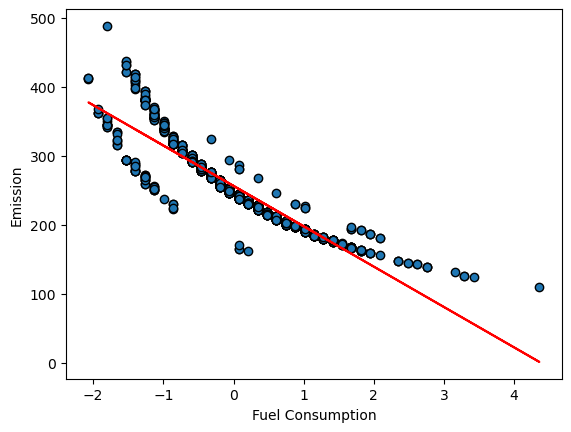

In [73]:
# Enter your code here
plt.scatter(X_train_2, y_train)
plt.plot(X_train_2, coef_2[0] * X_train_2 + intercept_2, '-r')
plt.xlabel("Fuel Consumption")
plt.ylabel("Emission")

Text(0, 0.5, 'CO2 Emission')

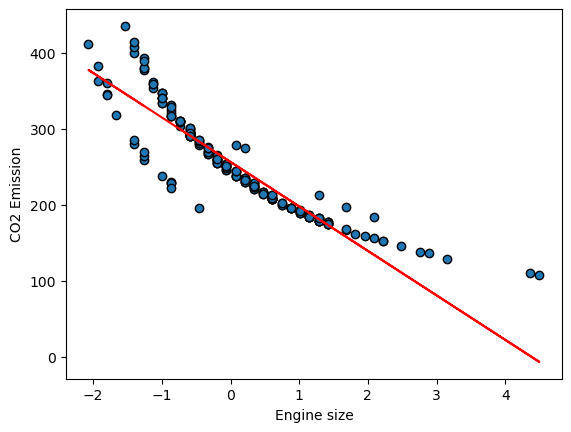

In [76]:
# Enter your code here
X_test_2 = X_test[:,1]
plt.scatter(X_test_2, y_test)
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2, '-r')
plt.xlabel("Fuel Consumption")
plt.ylabel("CO2 Emission")